# Import Library

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    f1_score
)

import joblib

pd.set_option("display.max_columns", None)

# Load Dataset

In [49]:
users = pd.read_csv('/kaggle/input/datasets/anujsaha0123456789/e-commerce-product-intelligence-dataset/users.csv')
products = pd.read_csv('/kaggle/input/datasets/anujsaha0123456789/e-commerce-product-intelligence-dataset/products.csv')
sessions = pd.read_csv('/kaggle/input/datasets/anujsaha0123456789/e-commerce-product-intelligence-dataset/sessions.csv')
interactions = pd.read_csv('/kaggle/input/datasets/anujsaha0123456789/e-commerce-product-intelligence-dataset/interactions.csv')
purchases = pd.read_csv('/kaggle/input/datasets/anujsaha0123456789/e-commerce-product-intelligence-dataset/purchases.csv')
reviews = pd.read_csv('/kaggle/input/datasets/anujsaha0123456789/e-commerce-product-intelligence-dataset/reviews.csv')

## Quick dataset

In [50]:
datasets = {
    "users": users,
    "products": products,
    "sessions": sessions,
    "interactions": interactions,
    "purchases": purchases,
    "reviews": reviews
}

for name, df in datasets.items():
    print("="*50)
    print(name)
    print(df.shape)
    print(df.isnull().sum().sum())

users
(10000, 9)
0
products
(1000, 11)
548
sessions
(19315, 6)
0
interactions
(100000, 7)
0
purchases
(1737, 10)
0
reviews
(1253, 8)
200


## Create Purchase Label

In [51]:
purchase_interactions = purchases["interaction_id"].unique()

interactions["purchase_label"] = (
    interactions["interaction_id"]
    .isin(purchase_interactions)
    .astype(int)
)

interactions["purchase_label"].value_counts(normalize=True)

df = interactions.merge( users, on="user_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(
    sessions[
        [
            "session_id",
            "device_type",
            "referrer_source"
        ]
    ],
    on="session_id",
    how="left"
)

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month
df["weekend"] = (df["dayofweek"] >= 5).astype(int)
df["customer_days"] = (df["timestamp"] - df["signup_date"]).dt.days

## Feature Engine

In [52]:
df = df.sort_values("timestamp")
df["user_prev_interactions"] = (df.groupby("user_id").cumcount())
df["product_prev_interactions"] = (df.groupby("product_id").cumcount())
df["user_avg_dwell_before"] = (df.groupby("user_id")["dwell_time_ms"].transform(lambda x:x.shift().expanding().mean()))
df["product_avg_dwell_before"] = (df.groupby("product_id")["dwell_time_ms"].transform(lambda x:x.shift().expanding().mean()))
df["user_prev_purchase_count"] = (df.groupby("user_id")["purchase_label"].cumsum() - df["purchase_label"])
df["product_prev_purchase_count"] = (df.groupby("product_id")["purchase_label"].cumsum() - df["purchase_label"])
df["user_hist_conversion"] = (df["user_prev_purchase_count"] / (df["user_prev_interactions"] + 1))
df["product_hist_conversion"] = (df["product_prev_purchase_count"] / (df["product_prev_interactions"] + 1))
df["category_match"] = (df["preferred_category"] == df["category"]).astype(int)

for col in df.columns:
    if df[col].dtype != "object":
        df[col] = df[col].fillna(0)

# EDA

0.01737


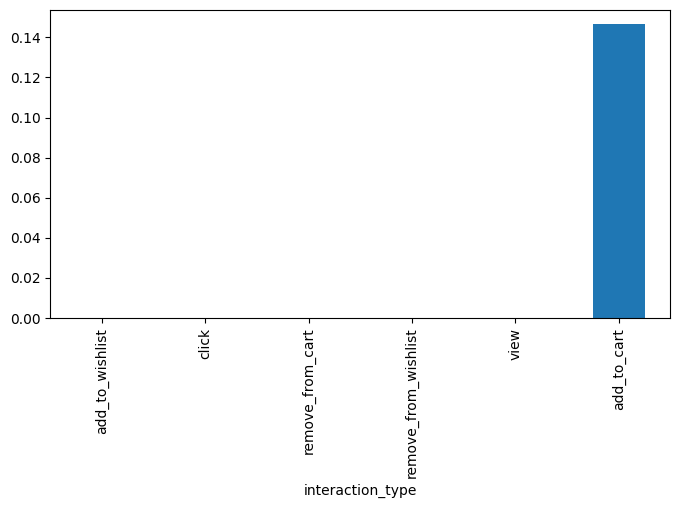

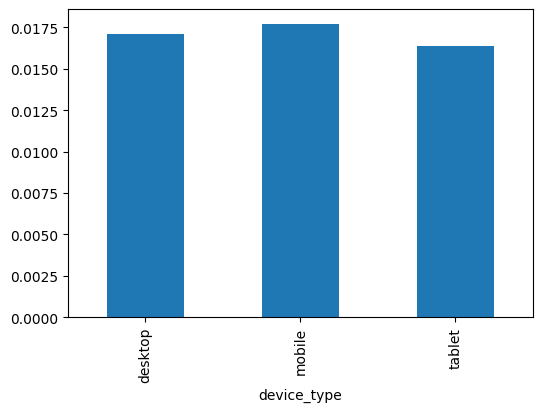

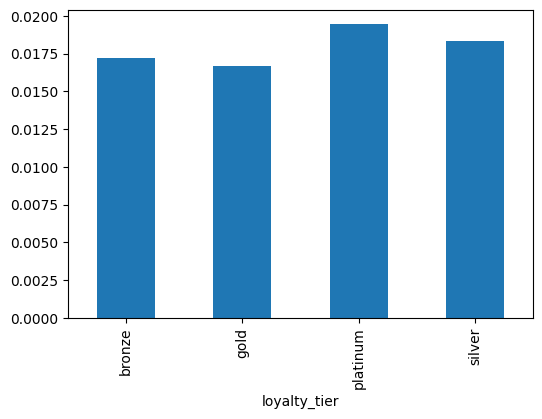

In [53]:
print(df["purchase_label"].mean())

plt.figure(figsize=(8,4))
(df.groupby("interaction_type")["purchase_label"].mean().sort_values()).plot(kind="bar")
plt.show()

plt.figure(figsize=(6,4))
(df.groupby("device_type")["purchase_label"].mean()).plot(kind="bar")
plt.show()

plt.figure(figsize=(6,4))
(df.groupby("loyalty_tier")["purchase_label"].mean()).plot(kind="bar")
plt.show()

In [54]:
df = df.sort_values("timestamp")

split_index = int(len(df)*0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(train_df.shape)
print(test_df.shape)

(80000, 42)
(20000, 42)


# Feature Selection

In [55]:
TARGET = "purchase_label"

DROP_COLS = [
    TARGET,
    "interaction_id",
    "session_id",
    "user_id",
    "product_id",
    "timestamp",
    "signup_date",
    "product_name",
    "product_description"
]

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET]
X_test = test_df.drop(columns=DROP_COLS)
y_test = test_df[TARGET]

# Model Training & Evaluation

In [56]:
cat_features = X_train.select_dtypes(include="object").columns.tolist()
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), use_best_model=True)

probs = model.predict_proba(X_test)[:,1]
roc_auc_score(y_test, probs)
precision, recall, thresholds = precision_recall_curve(y_test, probs)

scores = []

for t in thresholds:
    pred = (probs > t).astype(int)
    scores.append(f1_score( y_test, pred))

best_idx = np.argmax(scores)
best_threshold = thresholds[best_idx]
best_threshold

preds = (probs > best_threshold).astype(int)

0:	test: 0.9535509	best: 0.9535509 (0)	total: 137ms	remaining: 2m 16s
100:	test: 0.9600174	best: 0.9601435 (91)	total: 14.5s	remaining: 2m 9s
200:	test: 0.9593297	best: 0.9601435 (91)	total: 30.2s	remaining: 2m
300:	test: 0.9574733	best: 0.9601435 (91)	total: 46.6s	remaining: 1m 48s
400:	test: 0.9559186	best: 0.9601435 (91)	total: 1m 2s	remaining: 1m 33s
500:	test: 0.9551850	best: 0.9601435 (91)	total: 1m 18s	remaining: 1m 18s
600:	test: 0.9543190	best: 0.9601435 (91)	total: 1m 35s	remaining: 1m 3s
700:	test: 0.9538448	best: 0.9601435 (91)	total: 1m 50s	remaining: 47.3s
800:	test: 0.9529818	best: 0.9601435 (91)	total: 2m 7s	remaining: 31.7s
900:	test: 0.9527401	best: 0.9601435 (91)	total: 2m 23s	remaining: 15.8s
999:	test: 0.9525435	best: 0.9601435 (91)	total: 2m 39s	remaining: 0us

bestTest = 0.9601434803
bestIteration = 91

Shrink model to first 92 iterations.


              precision    recall  f1-score   support

           0       0.99      0.97      0.98     19646
           1       0.21      0.49      0.30       354

    accuracy                           0.96     20000
   macro avg       0.60      0.73      0.64     20000
weighted avg       0.98      0.96      0.97     20000



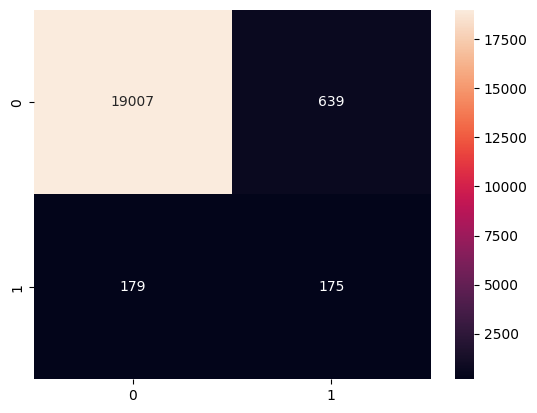

In [57]:
print(classification_report(y_test, preds))

cm = confusion_matrix( y_test, preds)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

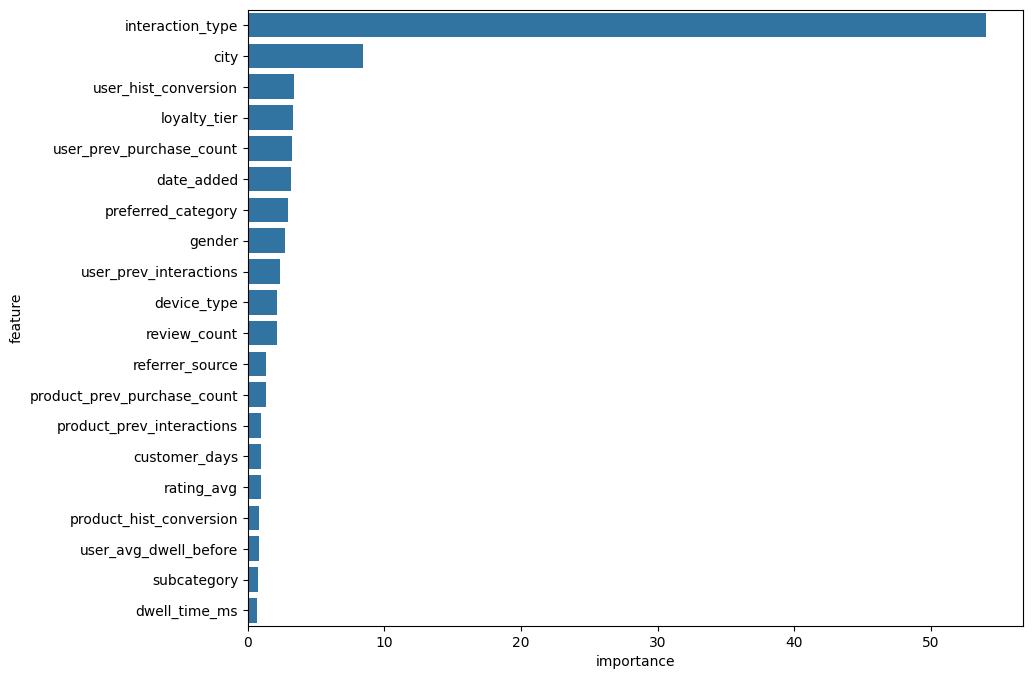

In [58]:
importance = pd.DataFrame({"feature": X_train.columns, "importance": model.feature_importances_})
importance = importance.sort_values("importance", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=importance.head(20), x="importance", y="feature")
plt.show()

In [ ]:
for t in [0.03,0.05,0.07,0.10,0.15,0.20]:

    pred = (probs >= t).astype(int)

    print(
        f"T={t}",
        f"P={precision_score(y_test,pred,zero_division=0):.3f}",
        f"R={recall_score(y_test,pred):.3f}",
        f"F1={f1_score(y_test,pred):.3f}"
    )

T=0.03 P=0.149 R=1.000 F1=0.259
T=0.05 P=0.149 R=0.986 F1=0.259
T=0.07 P=0.156 R=0.935 F1=0.267
T=0.1 P=0.175 R=0.771 F1=0.286
T=0.15 P=0.275 R=0.206 F1=0.236
T=0.2 P=0.200 R=0.020 F1=0.036


In [60]:
test_result = pd.DataFrame({
    "actual": y_test,
    "score": probs
})

test_result = test_result.sort_values(
    "score",
    ascending=False
)

top10 = test_result.head(
    int(len(test_result)*0.1)
)

lift = (
    top10["actual"].mean()
    /
    test_result["actual"].mean()
)

print("Lift@10% =", lift)

Lift@10% = 8.813559322033898



* Users who have added_to_cart have a much higher probability of conversion than users who only view or click.
* Customers with previous purchase history have a higher chance of conversion than new customers.


In [61]:
import joblib

joblib.dump(model, "purchase_conversion_model.pkl")

['purchase_conversion_model.pkl']